# Optical conductivity from the Kubo-Greenwood formula
Let us see how a Chern insulator absorbs light, with `h.get_optical_conductivity()`. The
conductivity tensor $\sigma_{ab}(\omega)$ is computed with the Kubo-Greenwood formula, summing
the velocity matrix elements between occupied and empty bands over a k-mesh, so that light of
frequency $\omega$ is absorbed whenever it can move an electron from an occupied to an empty
band separated by $\hbar\omega$. The real part of $\sigma_{xx}$ is the optical absorption, the
off-diagonal $\sigma_{xy}$ is the magneto-optical response behind the Kerr and Faraday
rotations, and the zero-frequency limit of $\sigma_{xy}$ is the Hall conductivity, quantized to
$-C\,e^2/h$ for a Chern insulator with Chern number $C$. Results are in units of $e^2/\hbar$, so
one conductance quantum $e^2/h$ is $1/(2\pi)$ of the returned value.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### Absorption across a topological phase transition
We take the Haldane model, the honeycomb lattice with an imaginary second-neighbor hopping
$t_2$, and add a sublattice imbalance $m$. As $m$ grows the gap closes at one of the two
valleys and opens again, and the system goes from a Chern insulator with $C=\pm1$ to a trivial
insulator with $C=0$. The maps show $\mathrm{Re}\,\sigma_{xx}$ and $\mathrm{Re}\,\sigma_{xy}$ as
a function of the frequency and of $m$, with the gap drawn on top.

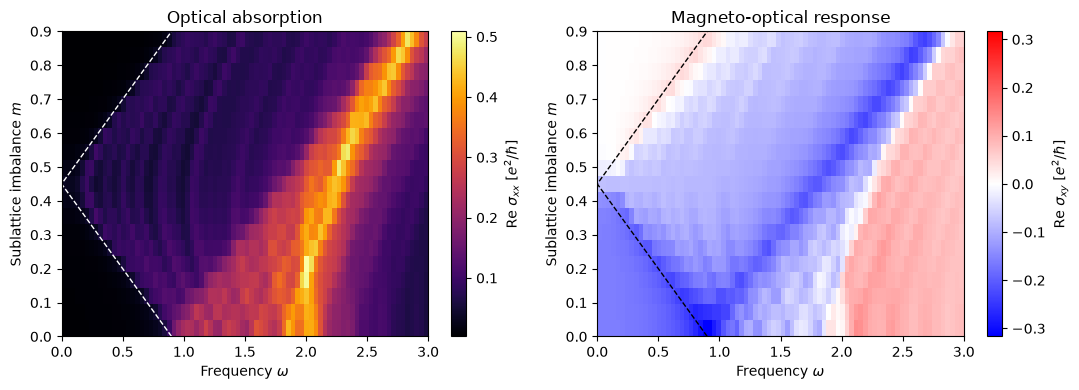

In [2]:
g = geometry.honeycomb_lattice() # honeycomb lattice
ms = np.linspace(0.,0.9,19) # sublattice imbalances
ws = np.linspace(0.,3.,80) # frequencies
sxx,sxy,gaps,hall = [],[],[],[] # storage
for m in ms:
    h = g.get_hamiltonian(has_spin=False) # spinless Hamiltonian
    h.add_haldane(0.1) # Haldane coupling, a Chern insulator
    h.add_sublattice_imbalance(m) # sublattice imbalance, a trivial mass
    (w,s) = h.get_optical_conductivity(energies=ws,nk=40,T=0.02,delta=0.05)
    sxx.append(s[:,0,0].real) # optical absorption
    sxy.append(s[:,0,1].real) # magneto-optical response
    (w0,s0) = h.get_optical_conductivity(energies=[0.],nk=60,T=0.01,delta=1e-3)
    hall.append(2.*np.pi*s0[0,0,1].real) # DC Hall conductivity in e^2/h
    gaps.append(h.get_gap()) # single-particle gap

extent = [ws[0],ws[-1],ms[0],ms[-1]]
fig,axs = plt.subplots(1,2,figsize=(11,4))
im = axs[0].imshow(np.array(sxx),origin="lower",aspect="auto",extent=extent,cmap="inferno")
fig.colorbar(im,ax=axs[0],label=r"Re $\sigma_{xx}$ [$e^2/\hbar$]")
axs[0].set_title("Optical absorption")
v = np.max(np.abs(sxy))
im = axs[1].imshow(np.array(sxy),origin="lower",aspect="auto",extent=extent,cmap="bwr",vmin=-v,vmax=v)
fig.colorbar(im,ax=axs[1],label=r"Re $\sigma_{xy}$ [$e^2/\hbar$]")
axs[1].set_title("Magneto-optical response")
for ax,c in zip(axs,["white","black"]):
    ax.plot(gaps,ms,c=c,ls="--",lw=1) # the gap
    ax.set_xlabel(r"Frequency $\omega$") ; ax.set_ylabel("Sublattice imbalance $m$")
plt.tight_layout()
plt.show()

The absorption is zero below the gap and switches on at it, so the onset follows the dashed
line down to zero at the transition and up again after it. Below the gap
$\mathrm{Re}\,\sigma_{xy}$ stays at its zero-frequency value, one conductance quantum
$1/(2\pi)$ in the Chern insulator and zero in the trivial one, and it only acquires structure
above the absorption edge, where the interband transitions set in. The zero-frequency limit is
the Hall conductivity, shown below as a function of $m$: a plateau at $-1$ and a plateau at $0$.
Close to the transition the gap becomes smaller than what the k-mesh resolves, and there the
computed value is not quantized.

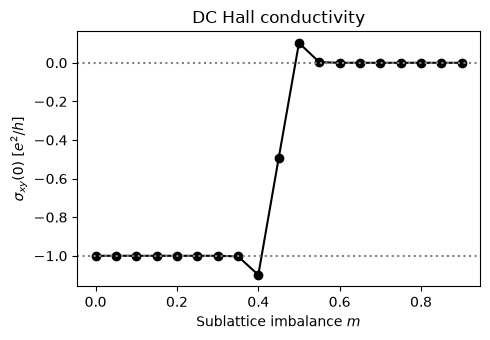

In [3]:
plt.figure(figsize=(5,3.5))
plt.plot(ms,hall,marker="o",c="black")
plt.axhline(-1.,c="gray",ls=":") ; plt.axhline(0.,c="gray",ls=":")
plt.xlabel("Sublattice imbalance $m$") ; plt.ylabel(r"$\sigma_{xy}(0)$ [$e^2/h$]")
plt.title("DC Hall conductivity")
plt.tight_layout()
plt.show()